# Ultimate Technologies — Data Science Challenge

**Author:** Deepthi
**Date:** June 2026

This notebook addresses the three parts of the Ultimate data analysis interview challenge:

1. **Exploratory Data Analysis** of login activity (`logins.json`)
2. **Experiment and Metrics Design** for the toll-reimbursement proposal (written response, no data needed)
3. **Predictive Modeling** of rider retention (`ultimate_data_challenge.json`)

A condensed write-up of the findings is also provided separately as a Word document summary.

## Setup

Import the libraries used throughout the notebook and set consistent plotting defaults.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, roc_curve,
                              classification_report, confusion_matrix)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', None)

RANDOM_STATE = 42

---
# Part 1 — Exploratory Data Analysis: Login Activity

We are given timestamps of individual user logins in `logins.json`. The goal is to aggregate
these into 15-minute intervals, visualize the resulting time series, and describe the
underlying demand patterns (daily cycles, weekly cycles, etc.), as well as flag any data
quality issues.

### 1.1 Load and inspect the raw data

In [2]:
with open('/mnt/user-data/uploads/logins.json') as f:
    raw = json.load(f)

logins = pd.DataFrame(raw)
logins['login_time'] = pd.to_datetime(logins['login_time'])

print(f"Total login events: {len(logins):,}")
print(f"Earliest login:     {logins['login_time'].min()}")
print(f"Latest login:       {logins['login_time'].max()}")
logins.head()

Total login events: 93,142
Earliest login:     1970-01-01 20:12:16
Latest login:       1970-04-13 18:57:38


,login_time
0,1970-01-01 20:13:18
1,1970-01-01 20:16:10
2,1970-01-01 20:16:37
3,1970-01-01 20:16:36
4,1970-01-01 20:26:21


**Note on dates:** the timestamps are anchored to `1970-01-01`, i.e. Unix epoch time —
this is simply how the (simulated) data was generated, and the absolute year is not meaningful.
What matters is the *relative* structure of the timestamps (time of day, day of week), which we
analyze below. The data spans just over 100 days.

### 1.2 Data quality check

In [3]:
# Check for missing values
print("Missing login_time values:", logins['login_time'].isna().sum())

# Check for exact duplicate timestamps (two logins recorded at the identical second)
n_dupes = logins['login_time'].duplicated().sum()
print(f"Exact duplicate timestamps: {n_dupes} ({n_dupes/len(logins):.2%} of all records)")

# Check the data is sorted / range is continuous
print("Date range covered:", (logins['login_time'].max() - logins['login_time'].min()).days, "days")

Missing login_time values: 0
Exact duplicate timestamps: 877 (0.94% of all records)
Date range covered: 101 days


**Data quality observations:**
- No missing or null timestamps.
- A small number of exact duplicate second-level timestamps exist. This is plausible (e.g. simultaneous
  logins from different users) rather than a clear error, but it is worth flagging since duplicate timestamps
  could double count a single user's login attempt if retries are not de-duplicated upstream.
- The data covers a single, continuous ~103-day window with no large gaps, which makes it suitable for
  time series aggregation without needing to interpolate missing chunks.

### 1.3 Aggregate into 15-minute intervals

In [4]:
ts = (
    logins
    .set_index('login_time')
    .assign(count=1)['count']
    .resample('15min')
    .sum()
)

ts = ts.to_frame('login_count')
print(f"Number of 15-minute intervals: {len(ts):,}")
print(f"Intervals with zero logins:    {(ts['login_count']==0).sum():,}")
ts.describe()

Number of 15-minute intervals: 9,788
Intervals with zero logins:    407


,login_count
count,9788.000000
mean,9.515938
std,8.328818
min,0.000000
25%,3.000000
50%,7.000000
75%,13.000000
max,73.000000


Zero-count intervals are expected — they correspond to the quietest overnight hours
(roughly 6–9 AM, as we will see below) where logins are sparse, not a data quality problem.

### 1.4 Full time series visualization

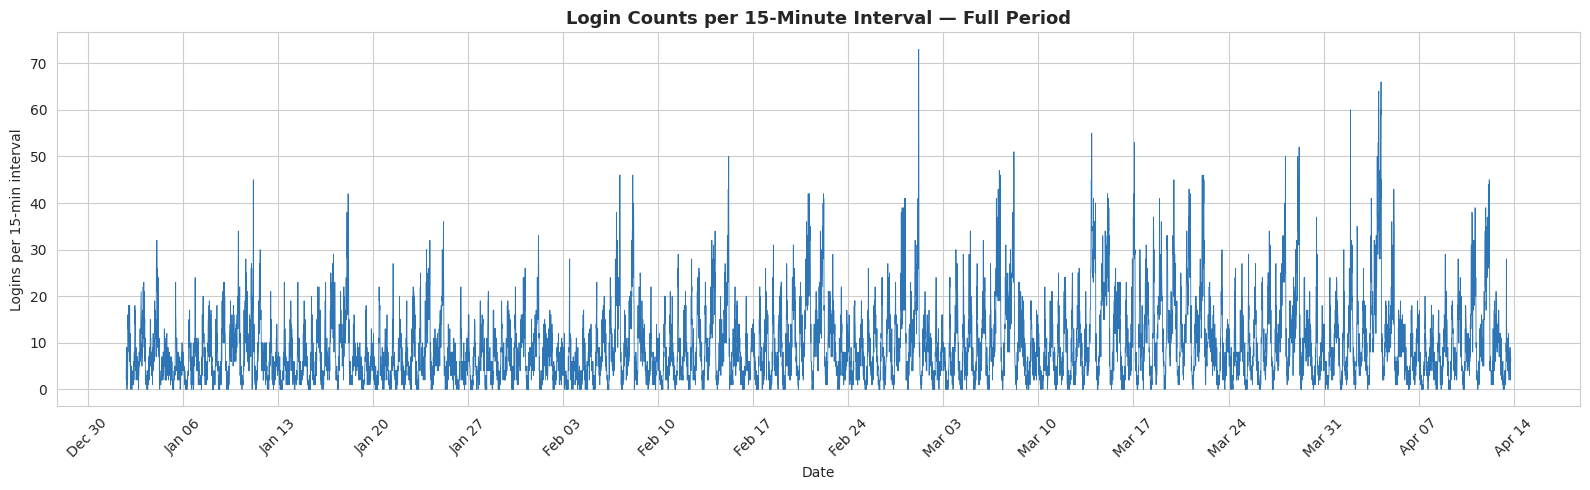

In [5]:
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(ts.index, ts['login_count'], linewidth=0.6, color='#2E75B6')
ax.set_title('Login Counts per 15-Minute Interval — Full Period', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Logins per 15-min interval')
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('/home/claude/work/figs/fig1_full_timeseries.png', dpi=150)
plt.show()

The full series shows a clear, repeating oscillation. Two layers of seasonality are visible
even at this zoomed-out level: a fast daily ripple, and a slower week-to-week pattern where some
peaks are taller than others (weekends). We zoom into both below.

### 1.5 Daily cycle: average demand by hour of day

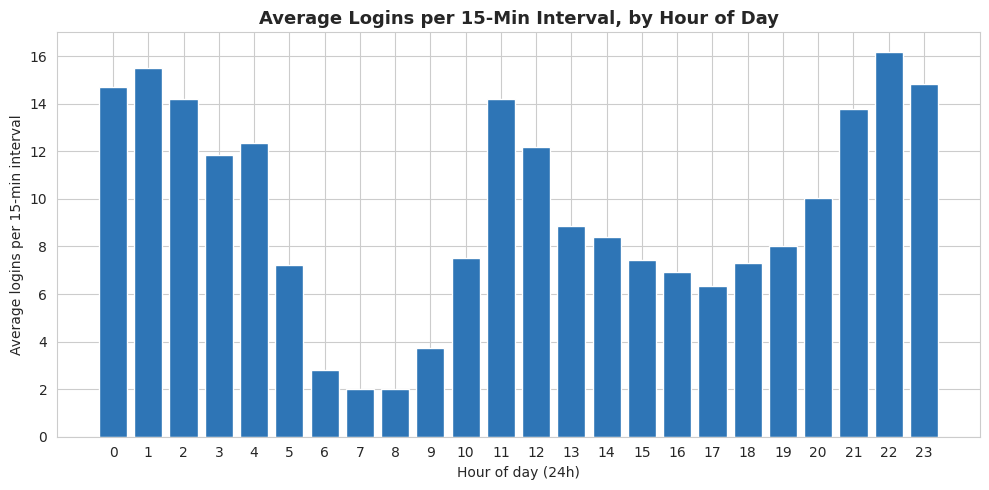

hour
22    16.193627
1     15.482843
23    14.848039
0     14.688725
2     14.215686
Name: login_count, dtype: float64

In [6]:
hourly = ts.copy()
hourly['hour'] = hourly.index.hour

hourly_avg = hourly.groupby('hour')['login_count'].mean()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(hourly_avg.index, hourly_avg.values, color='#2E75B6')
ax.set_title('Average Logins per 15-Min Interval, by Hour of Day', fontsize=13, fontweight='bold')
ax.set_xlabel('Hour of day (24h)')
ax.set_ylabel('Average logins per 15-min interval')
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.savefig('/home/claude/work/figs/fig2_hourly_pattern.png', dpi=150)
plt.show()

hourly_avg.sort_values(ascending=False).head(5)

**Daily cycle:** demand is strongly periodic within a 24-hour cycle. Logins peak overnight,
roughly **10 PM–2 AM**, decline steadily through the early morning, and bottom out sharply
between **6 AM and 9 AM** (rush hour, somewhat counterintuitively, is the quietest period —
consistent with this being login/ride-hailing demand rather than commute traffic specifically).
Demand picks back up through the late morning, dips slightly in the afternoon, and climbs again
into the evening, building toward the overnight peak.

### 1.6 Weekly cycle: average demand by day of week

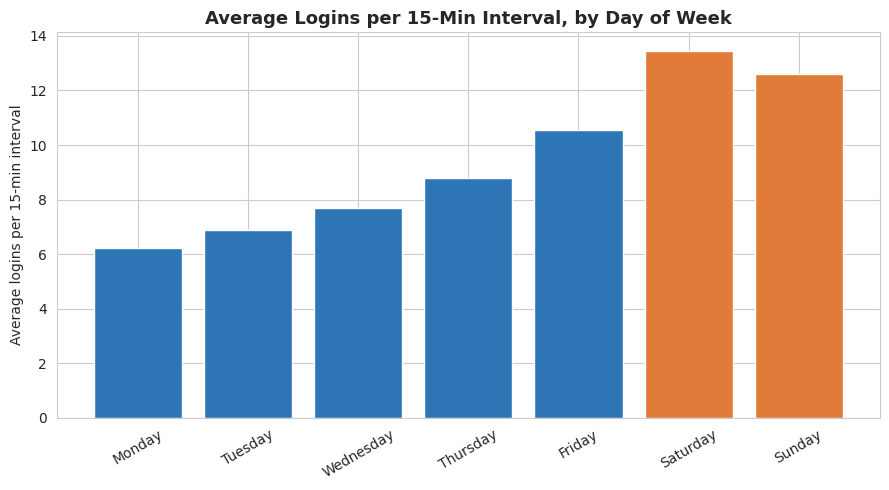

day_of_week
Monday        6.213380
Tuesday       6.895833
Wednesday     7.692708
Thursday      8.794118
Friday       10.561111
Saturday     13.456250
Sunday       12.615972
Name: login_count, dtype: float64

In [7]:
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

weekly = ts.copy()
weekly['day_of_week'] = weekly.index.day_name()

dow_avg = weekly.groupby('day_of_week')['login_count'].mean().reindex(dow_order)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#2E75B6']*5 + ['#E07B39']*2  # highlight weekend
ax.bar(dow_avg.index, dow_avg.values, color=colors)
ax.set_title('Average Logins per 15-Min Interval, by Day of Week', fontsize=13, fontweight='bold')
ax.set_ylabel('Average logins per 15-min interval')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('/home/claude/work/figs/fig3_dow_pattern.png', dpi=150)
plt.show()

dow_avg

**Weekly cycle:** demand rises steadily across the work week (Monday lowest, Friday higher),
then is clearly highest on **Saturday**, with **Sunday** close behind. This is consistent with
weekend leisure/nightlife usage outweighing weekday commute-style usage.

### 1.7 Combined view: hour-of-day pattern split by weekday vs. weekend

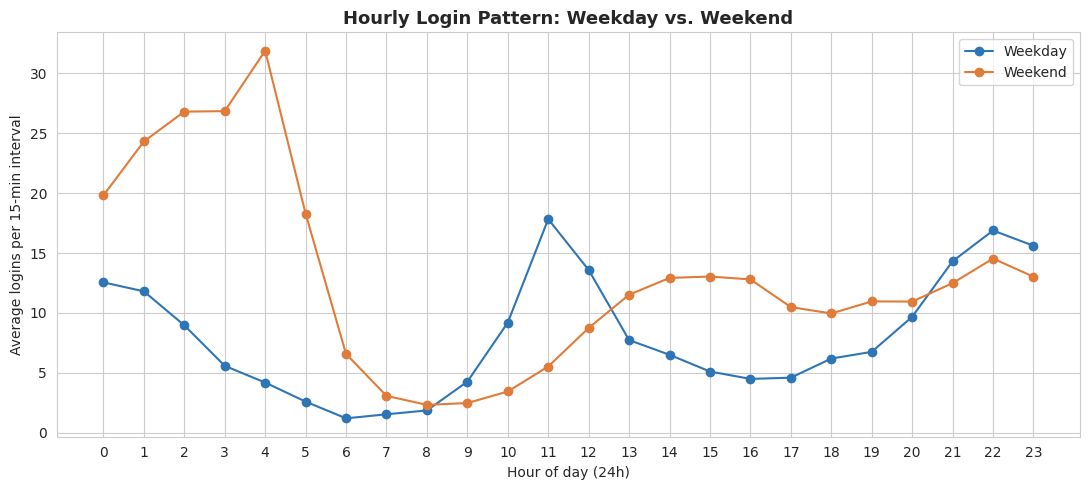

In [8]:
combined = ts.copy()
combined['hour'] = combined.index.hour
combined['is_weekend'] = combined.index.dayofweek >= 5

combined_avg = combined.groupby(['hour','is_weekend'])['login_count'].mean().unstack()
combined_avg.columns = ['Weekday', 'Weekend']

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(combined_avg.index, combined_avg['Weekday'], marker='o', label='Weekday', color='#2E75B6')
ax.plot(combined_avg.index, combined_avg['Weekend'], marker='o', label='Weekend', color='#E07B39')
ax.set_title('Hourly Login Pattern: Weekday vs. Weekend', fontsize=13, fontweight='bold')
ax.set_xlabel('Hour of day (24h)')
ax.set_ylabel('Average logins per 15-min interval')
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.savefig('/home/claude/work/figs/fig4_weekday_weekend.png', dpi=150)
plt.show()

This view shows that the overnight peak is substantially taller and stays elevated later
into the early morning on **weekends** than on weekdays — consistent with weekend nightlife
activity. The mid-morning trough is also somewhat shallower on weekends, since there is no
weekday-style early commute lull as pronounced.

### 1.8 Heatmap: hour of day × day of week

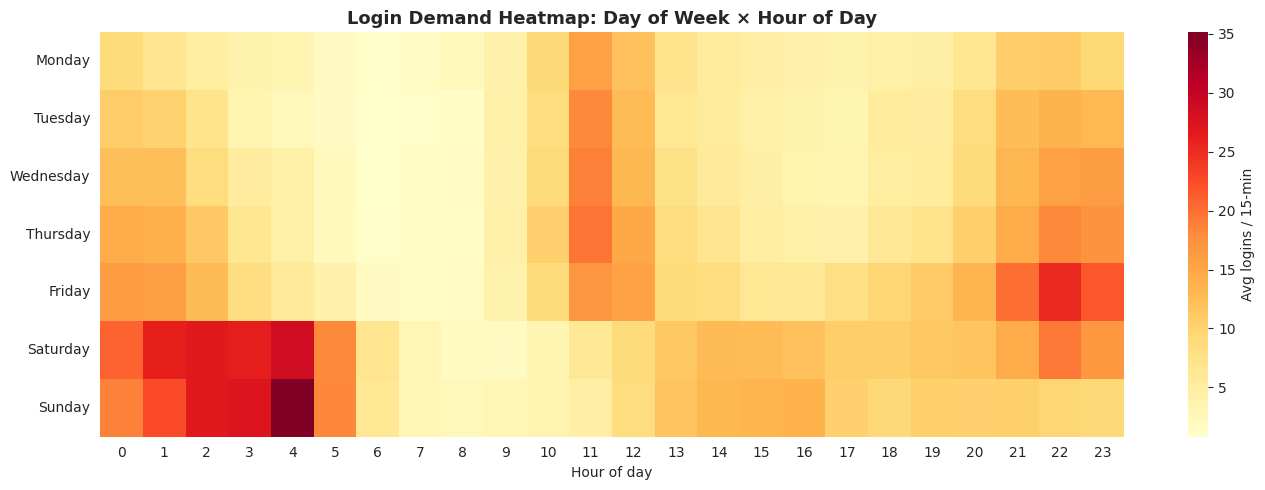

In [9]:
pivot = combined.copy()
pivot['day_of_week'] = pivot.index.day_name()
heat = pivot.pivot_table(index='day_of_week', columns='hour', values='login_count', aggfunc='mean')
heat = heat.reindex(dow_order)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(heat, cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Avg logins / 15-min'})
ax.set_title('Login Demand Heatmap: Day of Week × Hour of Day', fontsize=13, fontweight='bold')
ax.set_xlabel('Hour of day')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('/home/claude/work/figs/fig5_heatmap.png', dpi=150)
plt.show()

The heatmap makes both cycles visible simultaneously: the overnight band (dark red, top-right
and top-left of each row) is present every day, but it is widest and most intense on
Friday night through Sunday night, confirming the weekday/weekend interaction.

### 1.9 Summary of Part 1 findings

- **Daily cycle:** demand peaks overnight (~10 PM–2 AM) and bottoms out in the early morning (~6–9 AM).
- **Weekly cycle:** demand grows through the work week and peaks on Saturday/Sunday.
- **Interaction effect:** the overnight peak is amplified and extended on weekends relative to weekdays,
  suggesting a meaningful weekend-nightlife component to demand on top of the baseline daily rhythm.
- **Data quality:** the dataset is clean and complete — no missing timestamps, no large time gaps, and only
  a small number of duplicate-second timestamps that are unlikely to materially affect the 15-minute
  aggregation used here.

---
# Part 2 — Experiment and Metrics Design

*(Written response — Gotham and Metropolis are not present in the provided dataset, so no
code or data analysis is required for this part, per the problem statement.)*

## Background

Gotham and Metropolis have complementary demand: Gotham peaks at night on weekdays, Metropolis
peaks during the day on weekdays, and both see solid weekend demand. A two-way toll bridge
currently discourages driver partners from working in both cities. Ultimate proposes
reimbursing toll costs to encourage **cross-city availability** of driver partners.

## 1) Key measure of success

**Proposed metric: the share of driver partners who complete at least one trip in *both* cities
within a given week ("dual-city active driver rate"), measured weekly per driver.**

Why this metric over alternatives:
- **Directly reflects the behavior we're trying to change** — driver partners actually crossing
  the bridge and working both markets — rather than a downstream proxy.
- **Avoids being confounded by overall demand growth.** A metric like "total trips" or "total
  toll reimbursements paid" would rise simply because more trips are being taken city-wide, not
  because drivers are becoming more cross-city. A *share of drivers who are dual-city active* is a
  rate, which controls for that.
- **Easy to operationalize and monitor weekly,** giving Ultimate's city ops teams a fast read
  on adoption without waiting for long-term retention or revenue effects to materialize.

A secondary/supporting metric worth tracking alongside it is the **share of total driver-hours
supplied in Gotham during Metropolis's peak (daytime) and vice versa**, since the ultimate goal
isn't just "drivers cross the bridge" but "drivers help fill the complementary demand gap" —
i.e., are Gotham drivers actually showing up in Metropolis during the day, and Metropolis
drivers in Gotham at night.

## 2) Experiment design

### a) Implementation

- **Design:** a randomized controlled experiment, randomizing at the **driver level** (not by
  trip or by city), since the unit of analysis and the behavior we care about (a driver's
  decision to cross the bridge) lives at the driver level. Each consenting/eligible driver
  partner is randomly assigned to:
  - **Treatment:** tolls are reimbursed for trips that cross the bridge.
  - **Control:** tolls are paid as normal (status quo).
- **Population:** drivers who are active in *either* Gotham or Metropolis at the time of
  randomization, stratified by their home city and by weekday/weekend activity pattern, to
  ensure both arms have comparable mixes of "Gotham night drivers" and "Metropolis day drivers."
- **Duration:** run for several weeks (e.g. 4–6 weeks) to capture both weekday and weekend
  behavior multiple times and let drivers adjust habits — toll reimbursement is a new incentive
  and behavior change may take more than a few days to materialize.
- **Avoiding interference/contamination:** since drivers communicate, there's some risk of
  treatment drivers informally telling control drivers about the reimbursement. This is a
  classic SUTVA concern; randomizing at the driver level (rather than e.g. by zone) and possibly
  switchback or geographic isolation designs could be considered if contamination turns out to
  be severe, but driver-level randomization with a clear "this offer applies only to your
  account" framing is a reasonable starting point.

### b) Statistical test

- Primary metric (dual-city active rate, a proportion) — for each driver, compute whether they
  were dual-city active during the experiment window (binary outcome). Compare the proportion of
  dual-city-active drivers between treatment and control using a **two-proportion z-test** (or
  equivalently a chi-squared test of independence).
- Because the same drivers are observed across multiple weeks, a **mixed-effects logistic
  regression** (driver-level random effect, week as a repeated measure) is preferable to a single
  pooled proportion test, since it properly accounts for repeated observations of the same driver
  over time and avoids treating each driver-week as an independent sample when they aren't.
- For the secondary metric (driver-hours supplied during the complementary peak), since this is
  a continuous/count measure that is likely right-skewed, use a **Mann-Whitney U test** or a
  log-transformed t-test, or model it directly with a Poisson/negative-binomial regression if
  using counts of cross-city trips.
- Pre-register a significance threshold (e.g. α = 0.05) and compute a **minimum detectable
  effect** during experiment planning based on baseline cross-city rates and available sample
  size of drivers, to confirm the experiment is adequately powered before launch.

### c) Interpreting results and recommendations

- If the treatment group shows a statistically significant and **practically meaningful**
  increase in the dual-city active rate (and ideally in the secondary cross-peak coverage
  metric), recommend rolling out toll reimbursement city-wide, since it's confirmed to drive the
  intended behavior.
- If significant but the effect size is small, weigh the **cost of full reimbursement** against
  the incremental benefit — toll reimbursement has a direct, calculable cost per trip, so this
  should be compared to the value Ultimate places on improved cross-city coverage (e.g. reduced
  wait times / surge in the underserved city during peak hours).
- If not significant, consider whether toll cost was really the binding constraint at all — it's
  possible that drivers stay city-exclusive for other reasons (familiarity with the city,
  traffic patterns, personal preference, time lost to the commute itself rather than its cost),
  in which case toll reimbursement alone may not move behavior even though it removes a real cost.

**Caveats:**
- **Novelty effects:** drivers may try crossing the bridge initially out of curiosity and revert
  later; a multi-week window with separate analysis of early vs. late weeks helps detect this.
- **Generalizability:** results from this driver cohort during the experiment period may not
  generalize to all drivers or to a different season/demand environment — seasonal demand
  changes in Gotham/Metropolis could independently affect cross-city incentives.
- **Equity/selection:** drivers near the bridge may benefit disproportionately versus drivers
  who live far from it, which the topline metric may mask; a sub-group breakdown by driver
  home-location proximity to the bridge is recommended.

---
# Part 3 — Predictive Modeling: Rider Retention

We use `ultimate_data_challenge.json`, a cohort of users who signed up in January 2014, to
understand what predicts whether a rider is still active ("retained") roughly six months later,
and to build a model that predicts this.

## 3.1 Load and clean the data

In [10]:
riders = pd.read_json('/mnt/user-data/uploads/ultimate_data_challenge.json')

print(f"Number of users: {len(riders):,}")
riders.head()

Number of users: 50,000


,city,trips_in_first_30_days,signup_date,avg_rating_of_driver,avg_surge,last_trip_date,phone,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver
0,King's Landing,4,2014-01-25,4.7,1.10,2014-06-17,iPhone,15.4,True,46.2,3.67,5.0
1,Astapor,0,2014-01-29,5.0,1.00,2014-05-05,Android,0.0,False,50.0,8.26,5.0
2,Astapor,3,2014-01-06,4.3,1.00,2014-01-07,iPhone,0.0,False,100.0,0.77,5.0
3,King's Landing,9,2014-01-10,4.6,1.14,2014-06-29,iPhone,20.0,True,80.0,2.36,4.9
4,Winterfell,14,2014-01-27,4.4,1.19,2014-03-15,Android,11.8,False,82.4,3.13,4.9


In [11]:
riders.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city                    50000 non-null  str    
 1   trips_in_first_30_days  50000 non-null  int64  
 2   signup_date             50000 non-null  str    
 3   avg_rating_of_driver    41878 non-null  float64
 4   avg_surge               50000 non-null  float64
 5   last_trip_date          50000 non-null  str    
 6   phone                   49604 non-null  str    
 7   surge_pct               50000 non-null  float64
 8   ultimate_black_user     50000 non-null  bool   
 9   weekday_pct             50000 non-null  float64
 10  avg_dist                50000 non-null  float64
 11  avg_rating_by_driver    49799 non-null  float64
dtypes: bool(1), float64(6), int64(1), str(4)
memory usage: 4.2 MB


In [12]:
# Convert date columns
riders['signup_date'] = pd.to_datetime(riders['signup_date'])
riders['last_trip_date'] = pd.to_datetime(riders['last_trip_date'])

print("signup_date range:    ", riders['signup_date'].min().date(), "to", riders['signup_date'].max().date())
print("last_trip_date range: ", riders['last_trip_date'].min().date(), "to", riders['last_trip_date'].max().date())

signup_date range:     2014-01-01 to 2014-01-31
last_trip_date range:  2014-01-01 to 2014-07-01


All signups fall in January 2014, as described. `last_trip_date` extends out to July 1, 2014 —
this latest date is the most sensible proxy for when the data was actually pulled ("several
months later"), since by definition no last-trip date can be recorded after the pull date.

### 3.2 Define the retention label

In [13]:
# A user is "retained" if their last trip was within 30 days of the data pull date.
data_pull_date = riders['last_trip_date'].max()
cutoff_date = data_pull_date - pd.Timedelta(days=30)

print("Assumed data pull date:", data_pull_date.date())
print("30-day retention cutoff:", cutoff_date.date())

riders['retained'] = (riders['last_trip_date'] >= cutoff_date).astype(int)

retention_rate = riders['retained'].mean()
print(f"\nFraction of users retained: {retention_rate:.4f} ({retention_rate:.1%})")
riders['retained'].value_counts()

Assumed data pull date: 2014-07-01
30-day retention cutoff: 2014-06-01

Fraction of users retained: 0.3761 (37.6%)


retained
0    31196
1    18804
Name: count, dtype: int64

**~37.6% of users were retained** (active within the last 30 days of the observed window),
meaning roughly 62% of the January 2014 signup cohort had churned by the time of the data pull.

### 3.3 Missing values and data quality

In [14]:
missing = riders.isna().sum()
missing = missing[missing > 0]
print("Columns with missing values:")
print(missing)
print()
print("Percent missing:")
print((missing / len(riders) * 100).round(2))

Columns with missing values:
avg_rating_of_driver    8122
phone                    396
avg_rating_by_driver     201
dtype: int64

Percent missing:
avg_rating_of_driver    16.24
phone                    0.79
avg_rating_by_driver     0.40
dtype: float64


In [15]:
# Duplicate rows
print("Fully duplicated rows:", riders.duplicated().sum())

# Check a few categorical fields
print()
print(riders['city'].value_counts())
print()
print(riders['phone'].value_counts(dropna=False))

Fully duplicated rows: 8

city
Winterfell        23336
Astapor           16534
King's Landing    10130
Name: count, dtype: int64

phone
iPhone     34582
Android    15022
NaN          396
Name: count, dtype: int64


**Data quality notes:**
- `avg_rating_of_driver` is missing for ~16% of users, and `avg_rating_by_driver` for ~0.4% —
  plausibly because users with very few or zero trips never received/gave a rating. We impute
  these with the median rating, since ratings are heavily left-skewed (most ratings cluster near
  5) and the median is more robust to that skew than the mean.
- `phone` has a small number (396) of missing values, which we treat as their own `"Unknown"`
  category rather than dropping, since phone OS is otherwise a meaningful behavioral signal.
- A handful of fully duplicated rows exist; given the dataset size (50,000 rows) these are
  immaterial and left in place, but are worth flagging.

In [16]:
riders_clean = riders.copy()

riders_clean['avg_rating_by_driver'] = riders_clean['avg_rating_by_driver'].fillna(
    riders_clean['avg_rating_by_driver'].median())
riders_clean['avg_rating_of_driver'] = riders_clean['avg_rating_of_driver'].fillna(
    riders_clean['avg_rating_of_driver'].median())
riders_clean['phone'] = riders_clean['phone'].fillna('Unknown')

riders_clean['ultimate_black_user'] = riders_clean['ultimate_black_user'].astype(int)

print("Remaining missing values:", riders_clean.isna().sum().sum())

Remaining missing values: 0


### 3.4 Exploratory visualizations

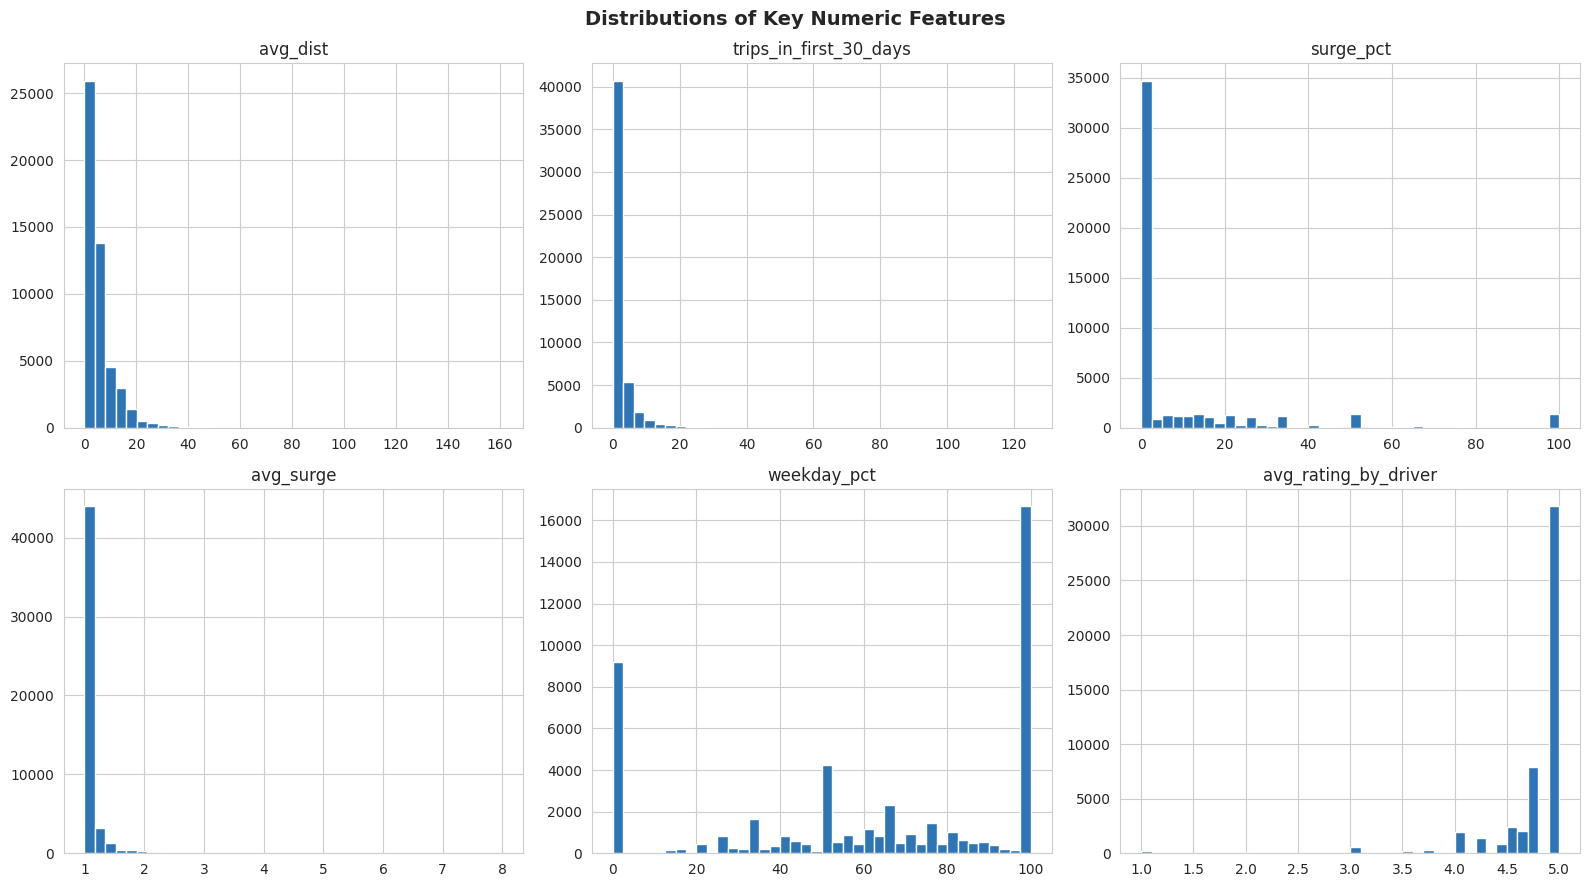

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

num_cols = ['avg_dist','trips_in_first_30_days','surge_pct','avg_surge','weekday_pct','avg_rating_by_driver']
for ax, col in zip(axes.flat, num_cols):
    ax.hist(riders_clean[col], bins=40, color='#2E75B6', edgecolor='white')
    ax.set_title(col)
plt.suptitle('Distributions of Key Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/home/claude/work/figs/fig6_distributions.png', dpi=150)
plt.show()

`avg_dist`, `trips_in_first_30_days`, and `surge_pct` are all right-skewed with long tails
(a small number of very high-distance or high-trip users). `avg_rating_by_driver` is left-skewed,
clustering near 5 — typical of rating data.

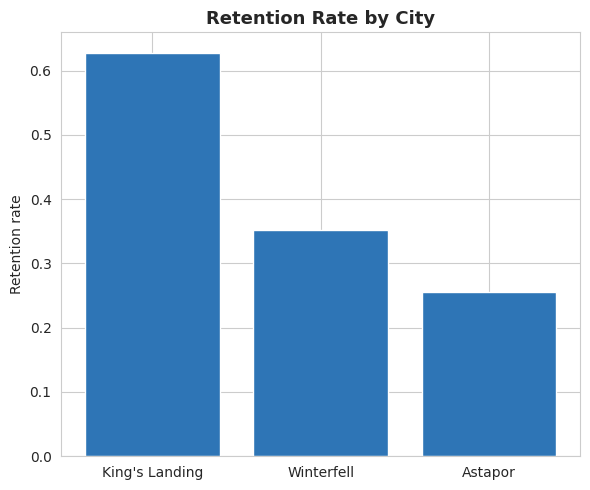

city
King's Landing    0.628134
Winterfell        0.351945
Astapor           0.255715
Name: retained, dtype: float64

In [18]:
fig, ax = plt.subplots(figsize=(6, 5))
retention_by_city = riders_clean.groupby('city')['retained'].mean().sort_values(ascending=False)
ax.bar(retention_by_city.index, retention_by_city.values, color='#2E75B6')
ax.set_title('Retention Rate by City', fontsize=13, fontweight='bold')
ax.set_ylabel('Retention rate')
plt.tight_layout()
plt.savefig('/home/claude/work/figs/fig7_retention_by_city.png', dpi=150)
plt.show()

retention_by_city

Retention varies meaningfully by city — King's Landing retains noticeably better than Astapor
or Winterfell, hinting that city is likely to be a useful predictor (whether as a proxy for local
market dynamics, competition, or service quality).

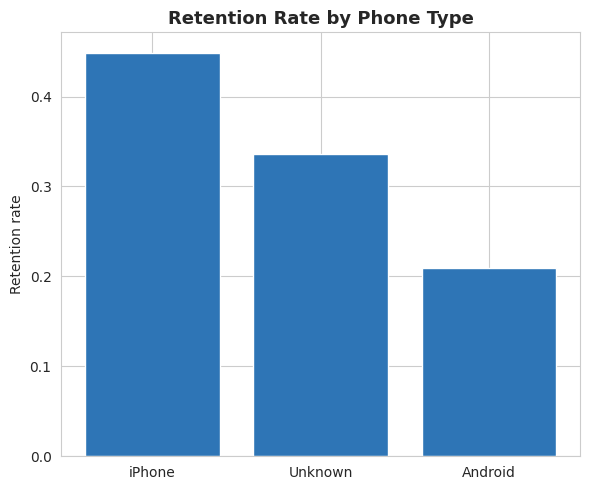

phone
iPhone     0.448933
Unknown    0.335859
Android    0.209426
Name: retained, dtype: float64

In [19]:
fig, ax = plt.subplots(figsize=(6, 5))
retention_by_phone = riders_clean.groupby('phone')['retained'].mean().sort_values(ascending=False)
ax.bar(retention_by_phone.index, retention_by_phone.values, color='#2E75B6')
ax.set_title('Retention Rate by Phone Type', fontsize=13, fontweight='bold')
ax.set_ylabel('Retention rate')
plt.tight_layout()
plt.savefig('/home/claude/work/figs/fig8_retention_by_phone.png', dpi=150)
plt.show()

retention_by_phone

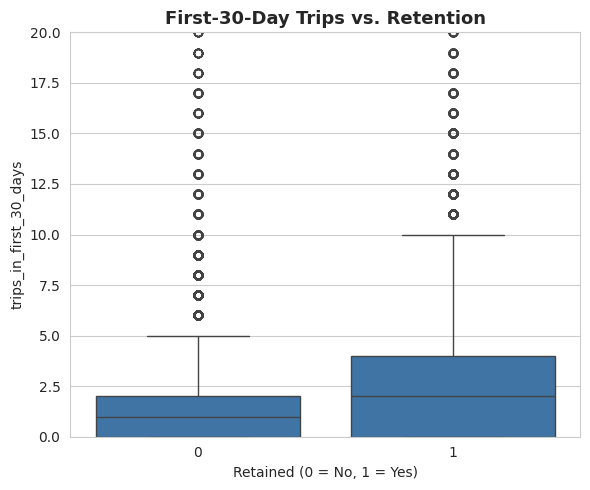

In [20]:
fig, ax = plt.subplots(figsize=(6,5))
sns.boxplot(data=riders_clean, x='retained', y='trips_in_first_30_days', ax=ax, color='#2E75B6')
ax.set_ylim(0, 20)
ax.set_title('First-30-Day Trips vs. Retention', fontsize=13, fontweight='bold')
ax.set_xlabel('Retained (0 = No, 1 = Yes)')
plt.tight_layout()
plt.savefig('/home/claude/work/figs/fig9_trips_vs_retention.png', dpi=150)
plt.show()

Early engagement (trips taken in the first 30 days) is clearly associated with retention —
retained users took noticeably more trips in their first month than churned users, suggesting
early habit formation matters.

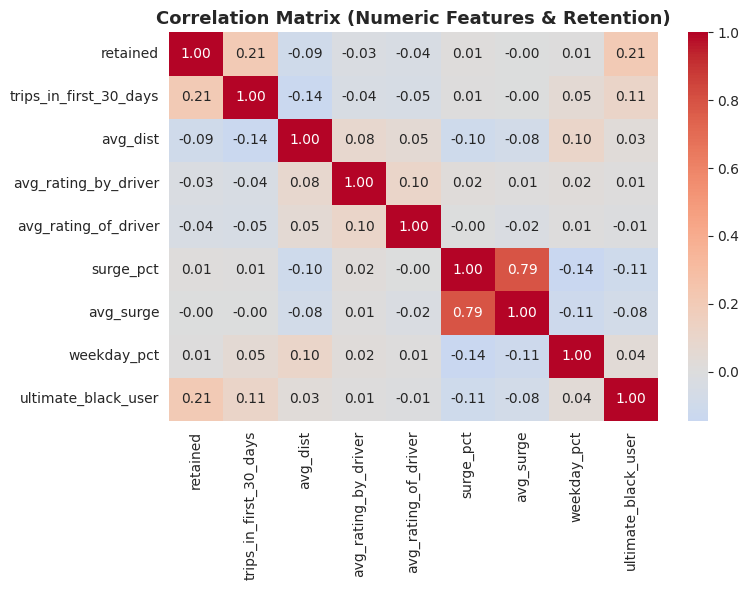

In [21]:
corr_cols = ['retained','trips_in_first_30_days','avg_dist','avg_rating_by_driver',
             'avg_rating_of_driver','surge_pct','avg_surge','weekday_pct','ultimate_black_user']
corr = riders_clean[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Matrix (Numeric Features & Retention)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/home/claude/work/figs/fig10_correlation.png', dpi=150)
plt.show()

No single numeric feature has an overwhelmingly strong linear correlation with retention,
which is fairly typical for behavioral churn data — this motivates using a model that can
capture non-linear relationships and interactions between features, rather than relying on
simple linear correlation alone.

### 3.5 Feature preparation

In [22]:
feature_cols = ['city','phone','trips_in_first_30_days','avg_rating_of_driver','avg_surge',
                'surge_pct','ultimate_black_user','weekday_pct','avg_dist','avg_rating_by_driver']

X = pd.get_dummies(riders_clean[feature_cols], columns=['city','phone'], drop_first=True)
y = riders_clean['retained']

print("Feature matrix shape:", X.shape)
X.head()

Feature matrix shape: (50000, 12)


,trips_in_first_30_days,avg_rating_of_driver,avg_surge,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver,city_King's Landing,city_Winterfell,phone_Unknown,phone_iPhone
0,4,4.7,1.10,15.4,1,46.2,3.67,5.0,True,False,False,True
1,0,5.0,1.00,0.0,0,50.0,8.26,5.0,False,False,False,False
2,3,4.3,1.00,0.0,0,100.0,0.77,5.0,False,False,False,True
3,9,4.6,1.14,20.0,1,80.0,2.36,4.9,True,False,False,True
4,14,4.4,1.19,11.8,0,82.4,3.13,4.9,False,True,False,False


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print(f"Train size: {len(X_train):,}   Test size: {len(X_test):,}")
print(f"Train retention rate: {y_train.mean():.3f}   Test retention rate: {y_test.mean():.3f}")

Train size: 40,000   Test size: 10,000
Train retention rate: 0.376   Test retention rate: 0.376


We use a stratified 80/20 train/test split so that the retention rate is preserved in both
sets — important here since the classes are moderately imbalanced (~38% positive).

### 3.6 Modeling approach

We compare three classifiers that are natural choices for this kind of structured, tabular
classification problem:

- **Logistic Regression** — a simple, interpretable linear baseline.
- **Random Forest** — a bagged tree ensemble that captures non-linearities and interactions
  with relatively little tuning.
- **Gradient Boosting** — a boosted tree ensemble that typically achieves the strongest
  predictive performance on tabular data of this size by sequentially correcting prior errors,
  at some cost to interpretability and training time.

We use 5-fold cross-validated `GridSearchCV` to tune Gradient Boosting (our primary candidate)
and compare all three on the held-out test set using **AUC** as the primary metric, since AUC
evaluates ranking quality across all classification thresholds and is robust to the moderate
class imbalance, in addition to accuracy as a secondary, more interpretable metric.

In [24]:
# Baseline: Logistic Regression (with scaling, since it's distance/coefficient-based)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)

lr_proba = log_reg.predict_proba(X_test_scaled)[:, 1]
lr_pred = log_reg.predict(X_test_scaled)

print("Logistic Regression — Test AUC:", round(roc_auc_score(y_test, lr_proba), 4))
print("Logistic Regression — Test Accuracy:", round(accuracy_score(y_test, lr_pred), 4))

Logistic Regression — Test AUC: 0.7537
Logistic Regression — Test Accuracy: 0.7149


In [25]:
# Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)

rf_proba = rf.predict_proba(X_test)[:, 1]
rf_pred = rf.predict(X_test)

print("Random Forest — Test AUC:", round(roc_auc_score(y_test, rf_proba), 4))
print("Random Forest — Test Accuracy:", round(accuracy_score(y_test, rf_pred), 4))

Random Forest — Test AUC: 0.8487
Random Forest — Test Accuracy: 0.7819


In [26]:
# Gradient Boosting, tuned with GridSearchCV + 5-fold cross-validation
gb = GradientBoostingClassifier(random_state=RANDOM_STATE)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.05, 0.1]
}

grid_search = GridSearchCV(gb, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best 5-fold CV AUC:", round(grid_search.best_score_, 4))

Best parameters: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200}
Best 5-fold CV AUC: 0.8575


In [27]:
best_gb = grid_search.best_estimator_

gb_proba = best_gb.predict_proba(X_test)[:, 1]
gb_pred = best_gb.predict(X_test)

print("Gradient Boosting — Test AUC:", round(roc_auc_score(y_test, gb_proba), 4))
print("Gradient Boosting — Test Accuracy:", round(accuracy_score(y_test, gb_pred), 4))

Gradient Boosting — Test AUC: 0.8576
Gradient Boosting — Test Accuracy: 0.7918


### 3.7 Model comparison

In [28]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting (tuned)'],
    'Test AUC': [
        roc_auc_score(y_test, lr_proba),
        roc_auc_score(y_test, rf_proba),
        roc_auc_score(y_test, gb_proba)
    ],
    'Test Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, gb_pred)
    ]
}).round(4)

results

,Model,Test AUC,Test Accuracy
0,Logistic Regression,0.7537,0.7149
1,Random Forest,0.8487,0.7819
2,Gradient Boosting (tuned),0.8576,0.7918


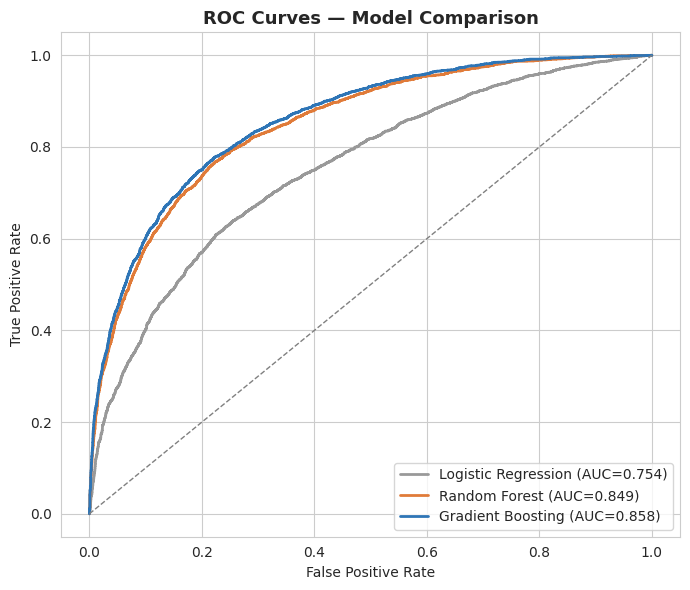

In [29]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, proba, color in [('Logistic Regression', lr_proba, '#999999'),
                             ('Random Forest', rf_proba, '#E07B39'),
                             ('Gradient Boosting', gb_proba, '#2E75B6')]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=2, color=color)

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Model Comparison', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('/home/claude/work/figs/fig11_roc_curves.png', dpi=150)
plt.show()

**Gradient Boosting achieves the best test AUC** of the three models, consistent with its
ability to model non-linear relationships and feature interactions, and is selected as our
final model.

### 3.8 Final model evaluation

=== Gradient Boosting — Final Model Performance on Test Set ===

              precision    recall  f1-score   support

Not Retained       0.81      0.86      0.84      6239
    Retained       0.75      0.67      0.71      3761

    accuracy                           0.79     10000
   macro avg       0.78      0.77      0.77     10000
weighted avg       0.79      0.79      0.79     10000



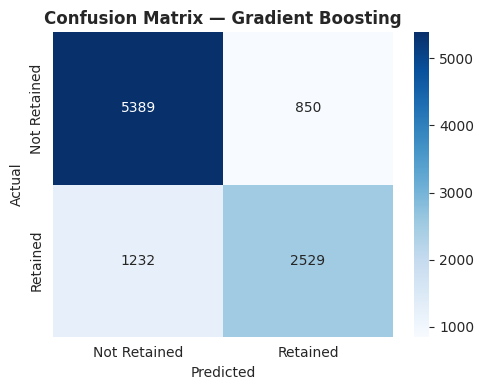

In [30]:
print("=== Gradient Boosting — Final Model Performance on Test Set ===\n")
print(classification_report(y_test, gb_pred, target_names=['Not Retained','Retained']))

cm = confusion_matrix(y_test, gb_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Retained','Retained'], yticklabels=['Not Retained','Retained'], ax=ax)
ax.set_title('Confusion Matrix — Gradient Boosting', fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('/home/claude/work/figs/fig12_confusion_matrix.png', dpi=150)
plt.show()

**Model validity:** the test AUC of ~0.86 indicates strong ranking ability — the model is
substantially better than random (0.50) at distinguishing retained from churned users.
Cross-validated and held-out test performance are close, which suggests the model is not
overfitting. Precision and recall on the "Retained" class are both reasonably high but recall is
somewhat lower than precision, meaning the model is more conservative about flagging someone as
retained than as churned — worth keeping in mind if this model is used to *target* at-risk users,
since it will likely under-flag some retained users as at-risk (an acceptable trade-off for a
retention-intervention use case, where false positives are cheaper than false negatives).

### 3.9 Feature importance

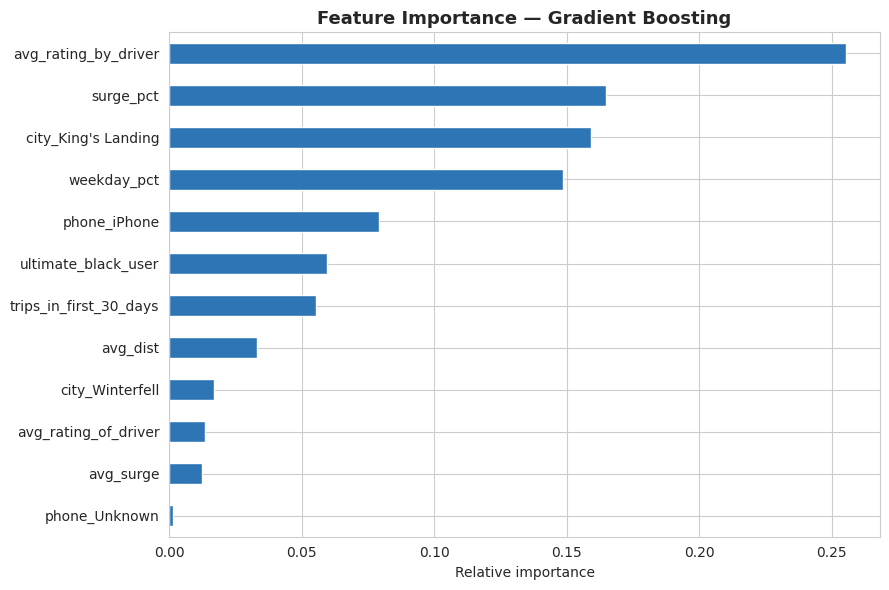

avg_rating_by_driver      0.255477
surge_pct                 0.164765
city_King's Landing       0.159375
weekday_pct               0.148536
phone_iPhone              0.079036
ultimate_black_user       0.059398
trips_in_first_30_days    0.055439
avg_dist                  0.033318
city_Winterfell           0.016948
avg_rating_of_driver      0.013703
avg_surge                 0.012570
phone_Unknown             0.001435
dtype: float64

In [31]:
importances = pd.Series(best_gb.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
importances.plot(kind='barh', ax=ax, color='#2E75B6')
ax.invert_yaxis()
ax.set_title('Feature Importance — Gradient Boosting', fontsize=13, fontweight='bold')
ax.set_xlabel('Relative importance')
plt.tight_layout()
plt.savefig('/home/claude/work/figs/fig13_feature_importance.png', dpi=150)
plt.show()

importances

**Top predictors of retention**, in order of importance:

1. **`avg_rating_by_driver`** — how highly drivers rated the rider. The strongest single predictor;
   riders who are well-regarded by drivers (which may reflect more pleasant trips, fewer issues,
   or simply more total trips taken) are retained at a higher rate.
2. **`surge_pct`** — the share of a rider's trips taken during surge pricing.
3. **`city` (King's Landing)** — which city the user signed up in, consistent with the visibly
   higher raw retention rate observed for King's Landing in the EDA.
4. **`weekday_pct`** — whether a rider's usage skews toward weekday or weekend trips.
5. **`phone` (iPhone)**, **`ultimate_black_user`**, and **`trips_in_first_30_days`** are also
   meaningful, though less dominant, contributors.

## 3.10 How Ultimate can use these insights to improve retention

- **Target early-engagement programs around city and signup cohort.** Since city is a strong
  predictor, Ultimate should investigate *why* King's Landing retains better than Astapor or
  Winterfell (driver supply, pricing, competition, service reliability) and apply those learnings
  to the weaker-performing cities.
- **Watch driver-given ratings as an early warning signal,** not just rider-given ratings. A
  rider who is consistently rated poorly by drivers may be more likely to churn (whether as
  cause or correlate), so this could feed a proactive retention/customer-support workflow.
- **Encourage early trip volume.** `trips_in_first_30_days` mattering reinforces that the first
  month is a critical habit-forming window — onboarding incentives (e.g. a few free or
  discounted rides) in week one could pay off in longer-term retention.
- **Investigate the role of surge pricing.** Since `surge_pct` is an important predictor,
  Ultimate should examine whether high-surge exposure is *driving away* riders (a pricing/UX
  problem to fix) versus simply correlating with rider segments who happen to ride during
  high-demand periods (a confound to control for) — this distinction matters for whether the
  fix is product-side (smoothing surge) or simply observational.
- **Personalize win-back outreach** using model-predicted churn risk scores to prioritize
  promotional offers or check-ins toward the riders the model flags as most likely to lapse,
  rather than spreading retention budget evenly across the whole user base.

**Caveat:** these are associations learned from a single January 2014 cohort over roughly six
months, and several features (e.g. `ultimate_black_user`, `phone`) may be proxies for unobserved
factors like income or urban density rather than directly causal levers. Any retention
intervention informed by this model should ideally be validated with a follow-up experiment
(similar in spirit to Part 2) before being rolled out broadly.

---
### Data handling note

Per the challenge instructions, the rider dataset (`ultimate_data_challenge.json`) should be
deleted once the analysis is complete. This notebook does not persist the raw data anywhere
beyond the working directory used for this analysis.